# PCA Full

Same pipeline as baseline_pca, but here fit on **all** nominal training windows instead of a 50k random subsample.

**Why:** baseline_pca uses `rng.choice(X_train_nom, size=PCA_FIT_SAMPLES)` and discards ~55% of the available nominal training data. This version uses every window w/o subsampling.

**Everything else identical to baseline_pca:**
- 80/20 temporal split (val set preserved for threshold tuning + F0.5 score)
- k chosen at 95% cumulative explained variance
- Window-mean MSE scoring, F0.5-sweep threshold

**Outputs:** `models/pca_full.pkl`, `submissions/pca_full.parquet`

## 0 - Setup & Imports

In [1]:
import gc
import json
import pickle
import sys
import time

sys.path.insert(0, '../src')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from sentinel.ml_logic.data import PROCESSED_DIR, MODELS_DIR, SUBMISSIONS_DIR, find_anomaly_segments
from sentinel.ml_logic.metrics import corrected_event_f05, f05_score
from sentinel.params import RANDOM_STATE, ANOMALY_COLOR, NOMINAL_COLOR

MODELS_DIR.mkdir(exist_ok=True)
SUBMISSIONS_DIR.mkdir(exist_ok=True)

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10})

print('Setup complete.')

Setup complete.


## 1 - Load Data

In [2]:
# Preprocessing config → window dimensions + temporal split index.
with open(PROCESSED_DIR / 'preprocessing_config.json') as f:
    cfg = json.load(f)

SPLIT_IDX = cfg['split_idx']
WIN       = cfg['window_size']     # 100
N_FEAT    = cfg['n_features']      # 58
WIN_FLAT  = WIN * N_FEAT           # 5800

print('Loading arrays …')
t0 = time.time()

# Nominal training windows — this is what PCA fits on. ALL of them, no subsample.
X_train_nom = np.load(PROCESSED_DIR / 'X_train_nom.npy')   # (~105k, 100, 58)

# Row-level arrays for val scoring + ground truth.
X_all = np.load(PROCESSED_DIR / 'train_full_scaled.npy')    # (~14.7M, 58)
y_all = np.load(PROCESSED_DIR / 'y_train_row.npy')

# Test rows for final submission.
X_test   = np.load(PROCESSED_DIR / 'test_scaled.npy')
test_ids = np.load(PROCESSED_DIR / 'test_ids.npy')

# Slice val out of the full row-level array, free the rest.
X_val = X_all[SPLIT_IDX:]
y_val = y_all[SPLIT_IDX:]
del X_all, y_all; gc.collect()

print(f'  loaded in {time.time()-t0:.1f}s')
print(f'  X_train_nom : {X_train_nom.shape}  ← fit on ALL of this')
print(f'  X_val       : {X_val.shape}  ({int(y_val.sum()):,} anomalous rows)')
print(f'  X_test      : {X_test.shape}')

Loading arrays …
  loaded in 2.7s
  X_train_nom : (105487, 100, 58)  ← fit on ALL of this
  X_val       : (2945665, 58)  (310,175 anomalous rows)
  X_test      : (521280, 58)


## 2 - Fit PCA on All Nominal Windows

Two-pass fit: probe PCA to find `k` for 95% variance, then refit at `k`. `X_fit` has shape `(n_train_nom, 5800)` - every available nominal window, flattened.

In [3]:
# Flatten (n, 100, 58) → (n, 5800). No subsampling — use every window.
X_fit = X_train_nom.reshape(len(X_train_nom), WIN_FLAT)
del X_train_nom; gc.collect()
print(f'X_fit: {X_fit.shape}  ({X_fit.nbytes/1e9:.2f} GB)')

# Pass 1: full PCA → read off k for 95% variance.
print(f'\nFitting probe PCA on {X_fit.shape[0]:,} nominal windows …')
t0 = time.time()
pca_probe = PCA(n_components=None, random_state=RANDOM_STATE)
pca_probe.fit(X_fit)
cum_var = np.cumsum(pca_probe.explained_variance_ratio_)
K = int(np.searchsorted(cum_var, 0.95)) + 1
print(f'  probe fit in {time.time()-t0:.1f}s  → k = {K} components for 95% variance')

# Pass 2: refit at the chosen k.
print(f'\nRefitting PCA with n_components={K} …')
t0 = time.time()
pca = PCA(n_components=K, random_state=RANDOM_STATE)
pca.fit(X_fit)
print(f'  refit in {time.time()-t0:.1f}s  (explained var: {pca.explained_variance_ratio_.sum()*100:.2f}%)')

with open(MODELS_DIR / 'pca_full.pkl', 'wb') as f:
    pickle.dump(pca, f)
print(f'  saved → {MODELS_DIR / "pca_full.pkl"}')

del X_fit; gc.collect()

X_fit: (105487, 5800)  (2.45 GB)

Fitting probe PCA on 105,487 nominal windows …
  probe fit in 101.7s  → k = 40 components for 95% variance

Refitting PCA with n_components=40 …
  refit in 26.3s  (explained var: 95.06%)
  saved → /Users/helena.schulz.ext/code/alexfederolf/sentinel/models/pca_full.pkl


0

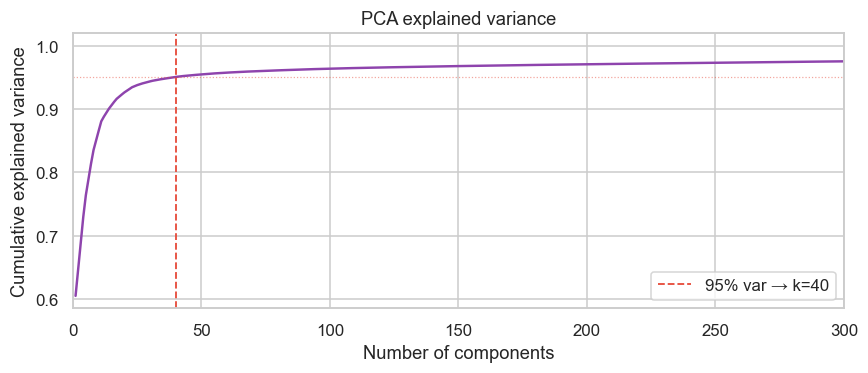

In [4]:
# Minimal diagnostic: cumulative explained variance, to sanity-check the chosen k.
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(np.arange(1, len(cum_var)+1), cum_var, color='#8e44ad', lw=1.6)
ax.axvline(K, ls='--', lw=1.2, color=ANOMALY_COLOR, label=f'95% var → k={K}')
ax.axhline(0.95, ls=':', lw=0.8, color=ANOMALY_COLOR, alpha=0.5)
ax.set(xlabel='Number of components', ylabel='Cumulative explained variance',
       title='PCA explained variance', xlim=(0, min(300, len(cum_var))))
ax.legend()
fig.tight_layout(); plt.show()

## 3 - Score Validation Set

Slide non-overlapping 100-row windows over `X_val`, reconstruct each with PCA, score = MSE per window. The window score is then broadcast back to every row in that window. Trailing rows (< `WIN`) inherit the last full window's score.

In [5]:
def score_windows(model: PCA, X_rows: np.ndarray, win: int = WIN,
               batch_windows: int = 5000) -> np.ndarray:
    """Row-level anomaly scores from window-level PCA MSE."""
    N, n_feat  = X_rows.shape
    n_complete = N // win
    flat_dim   = win * n_feat

    # 1) Compute MSE per window in batches (bounded memory).
    win_scores = np.empty(n_complete, dtype=np.float32)
    for b0 in range(0, n_complete, batch_windows):
        b1 = min(b0 + batch_windows, n_complete)
        batch = np.stack([
            X_rows[i*win:(i+1)*win].reshape(flat_dim) for i in range(b0, b1)
        ])
        rec = model.inverse_transform(model.transform(batch))
        win_scores[b0:b1] = ((batch - rec) ** 2).mean(axis=1)

    # 2) Broadcast to row-level.
    row_scores = np.empty(N, dtype=np.float32)
    for i in range(n_complete):
        row_scores[i*win:(i+1)*win] = win_scores[i]
    if n_complete * win < N and n_complete > 0:
        row_scores[n_complete*win:] = win_scores[-1]
    return row_scores

print(f'Scoring val ({len(X_val):,} rows) …')
t0 = time.time()
scores_val = score_windows(pca, X_val)
print(f'  done in {time.time()-t0:.1f}s')
print(f'  nominal mean MSE : {scores_val[y_val==0].mean():.5f}')
print(f'  anomaly mean MSE : {scores_val[y_val==1].mean():.5f}')

Scoring val (2,945,665 rows) …
  done in 1.3s
  nominal mean MSE : 0.06041
  anomaly mean MSE : 0.59312


## 4 - Tune Threshold on Val (F0.5 Sweep)

Same metric as NB04 (`corrected_event_f05`). We sweep a range of thresholds and pick the one that maximises the event-wise F0.5 score on the val set.

In [6]:
# Search range: nominal median → p99 of anomaly MSE.
# Using p99 instead of max guards against outlier-driven range explosion
# (a single MSE spike can stretch a linear grid so wide that the optimal
# threshold falls above all test scores, flagging nothing).
# Log-spacing (geomspace) keeps the grid dense near the decision boundary.
lo = float(np.percentile(scores_val[y_val==0], 50))
hi = float(np.percentile(scores_val[y_val==1], 99))
thresholds = np.geomspace(lo, hi, 60)

print(f'Sweeping {len(thresholds)} thresholds in [{lo:.5f}, {hi:.5f}] …')
t0 = time.time()
f05s = np.array([
    f05_score(y_val, (scores_val > t).astype(np.int8)) for t in thresholds
])
best_i     = int(np.argmax(f05s))
THRESHOLD  = float(thresholds[best_i])
best_f05   = float(f05s[best_i])
print(f'  swept in {time.time()-t0:.1f}s')
print(f'\nBest threshold : {THRESHOLD:.5f}  →  val F0.5 = {best_f05:.4f}')

# Full metric breakdown at the chosen threshold.
y_pred_val = (scores_val > THRESHOLD).astype(np.int8)
report = corrected_event_f05(y_val, y_pred_val)
print('\nVal metrics @ best threshold:')
for k, v in report.items():
    print(f'  {k:<16} {v}')

Sweeping 60 thresholds in [0.02743, 0.83887] …
  swept in 250.9s

Best threshold : 0.11028  →  val F0.5 = 0.7705

Val metrics @ best threshold:
  f_score          0.770489
  precision        0.854726
  recall           0.552632
  tp_events        21
  fn_events        17
  fp_pred_events   0
  fp_samples       382869
  tnr              0.854726


In [7]:
THRESHOLD

0.11027955300628543

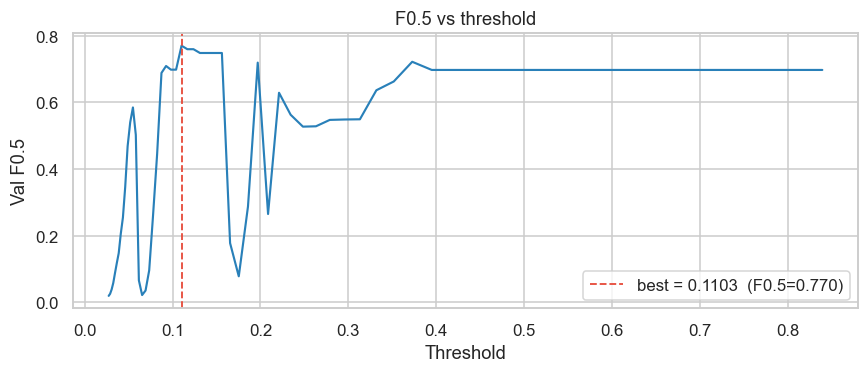

In [8]:
# F0.5 vs threshold plot to justify the operating point.
fig, ax = plt.subplots(figsize=(8, 3.5))
ax.plot(thresholds, f05s, color=NOMINAL_COLOR, lw=1.4)
ax.axvline(THRESHOLD, ls='--', lw=1.2, color=ANOMALY_COLOR,
           label=f'best = {THRESHOLD:.4f}  (F0.5={best_f05:.3f})')
ax.set(xlabel='Threshold', ylabel='Val F0.5', title='F0.5 vs threshold')
ax.legend()
fig.tight_layout(); plt.show()

## 5 - Score Test & Submission

In [9]:
print(f'Scoring test ({len(X_test):,} rows) …')
t0 = time.time()
scores_test = score_windows(pca, X_test)
print(f'  done in {time.time()-t0:.1f}s')

y_test = (scores_test > THRESHOLD).astype(np.int8)
n_flag = int(y_test.sum())
print(f'  flagged: {n_flag:,} / {len(y_test):,} rows  ({n_flag/len(y_test)*100:.2f}%)')

submission = pd.DataFrame({'id': test_ids, 'is_anomaly': y_test})
out_path = SUBMISSIONS_DIR / 'pca_full.parquet'
submission.to_parquet(out_path, index=False)
print(f'\nSubmission → {out_path}')

Scoring test (521,280 rows) …
  done in 0.3s
  flagged: 32,900 / 521,280 rows  (6.31%)

Submission → /Users/helena.schulz.ext/code/alexfederolf/sentinel/submissions/pca_full.parquet
